In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def beta_windows(a, b, window_size):
    a_s, b_s = pd.Series(a), pd.Series(b)
    roll = lambda s: s.rolling(window_size, min_periods=2)
    cov = roll(b_s).cov(a_s)          # cov(b, a)
    var = roll(b_s).var()              # var(b)
    betas = -(cov / var).to_numpy()
    betas = np.nan_to_num(betas, nan=0.0, posinf=0.0, neginf=0.0)
    return betas

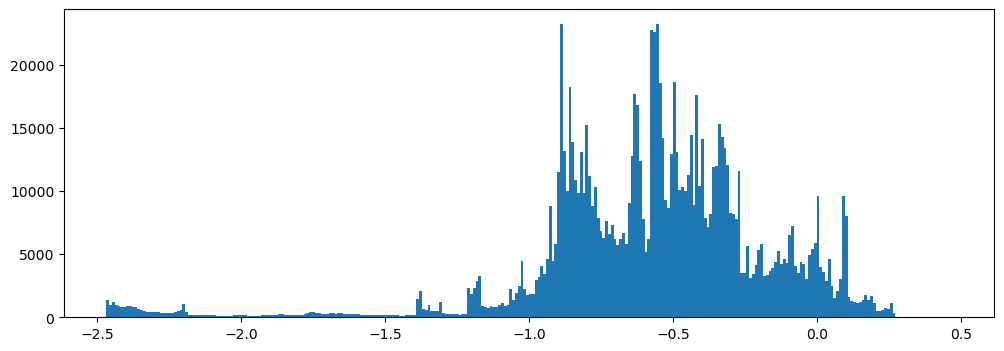

In [29]:
TRAIN_RATIO  = 0.80
CSV_A = '../dataset/CORN_USD_2005_2020.csv'   # ← change to your file
CSV_B = '../dataset/WHEAT_USD_2005_2020.csv'   # ← change to your file
CSV_C = '../data-scripts/data.csv'
# ─────────────────────────────────────────────────────────────────────

df_a = pd.read_csv(CSV_A).dropna()
df_b = pd.read_csv(CSV_B).dropna()
# df_a = pd.read_csv(CSV_C)[['s1']].dropna()
# df_b = pd.read_csv(CSV_C)[['s2']].dropna()
# df_a = df_a.rename(columns={"s1": "close"})
# df_b = df_b.rename(columns={"s2": "close"})
# df_a = df_a[int(0*len(df_a)):int(len(df_a))]
# df_b = df_b[int(0*len(df_b)):int(len(df_b))]
n = len(df_a)
A = df_a['close'].values
B = df_b['close'].values

split        = int(n * TRAIN_RATIO)
X = np.column_stack([np.ones(split), B[:split]])
beta_ols, _ = np.linalg.lstsq(X, A[:split], rcond=None)[0], None
beta      = beta_ols[1]

spread = A - beta * B
spread_train = spread[:split]
spread_test = spread[split:]
betas = beta_windows(A, B, 50000)
fig, ax = plt.subplots(figsize=(12, 4))  # wide & short
plt.hist(betas, bins=300)
plt.show()
betas_train = betas[:split]
betas_test = betas[split:]

In [35]:
from hmmlearn import hmm

model = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=100)
model.fit(betas_train.reshape(-1, 1))

,n_components,3
,covariance_type,'full'
,n_iter,100
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'


In [36]:
from scipy.special import logsumexp

def forward_states(model, obs):
    log_emit  = model._compute_log_likelihood(obs)
    log_trans = np.log(model.transmat_)
    log_alpha = np.log(model.startprob_) + log_emit[0]
    states    = [int(np.argmax(log_alpha))]
    for t in range(1, len(obs)):
        log_alpha = log_emit[t] + logsumexp(log_alpha[:, None] + log_trans, axis=0)
        states.append(int(np.argmax(log_alpha)))
    return np.array(states)

train_states = model.predict(betas_train.reshape(-1, 1))
test_states  = forward_states(model, betas_test.reshape(-1, 1))

C:\Users\lpset\AppData\Local\Temp\ipykernel_16480\2306484995.py:6: RuntimeWarning: divide by zero encountered in log
  log_alpha = np.log(model.startprob_) + log_emit[0]


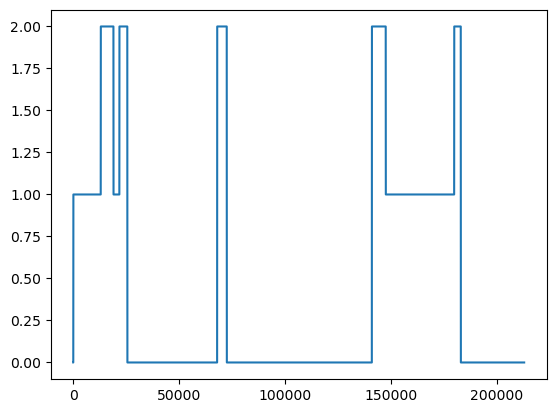

In [39]:
plt.plot(test_states)